# Bank Loan Risk & Customer Behavior Analysis

## Project Overview

This project analyzes a bank loan dataset to understand borrower behavior, loan characteristics, and factors associated with loan default risk. 

The analysis explores patterns in loan performance using exploratory data analysis (EDA), focusing on credit grade, interest rates, loan purpose, financial indicators, and borrower profiles. 

The goal is to identify key factors that influence loan risk and provide insights that could support better lending decisions.

## Problem Statement

Financial institutions issue thousands of loans every year. However, not all borrowers successfully repay their loans. Some borrowers default, which leads to financial loss for the bank.

The goal of this case study is to analyze historical loan data to understand:

- Borrower characteristics

- Loan performance

- Risk patterns

- Financial behavior of customers

This analysis helps answer an important business question:

Which type of customers are more likely to repay loans and which ones are more risky?

## Objective of the Analysis

- Understand borrower demographics and financial characteristics
- Identify patterns in loan repayment behavior
- Detect key factors associated with loan defaults
- Analyze borrower financial indicators such as income and debt-to-income ratio
- Generate insights that can help lenders better manage lending risk

## Dataset Description

The dataset contains historical loan records with borrower details, financial attributes, and loan performance information.

- id -	Unique loan ID
- member_id	- Unique borrower ID
- address_state - Borrower's state
- application_type - Individual or joint loan
- emp_length- Employment duration
- emp_title - Borrower's job title
- grade	- Loan risk grade assigned by bank
- sub_grade	- Detailed risk category
- home_ownership - Borrower's housing status
- purpose - Reason for taking the loan
- term - Loan duration
- loan_amount - Total loan amount
- int_rate - Interest rate
- installment - Monthly payment
- annual_income - Borrower's yearly income
- dti - Debt-to-income ratio
- total_acc - Total credit accounts
- total_payment	- Total amount repaid
- loan_status - Current status of loan
- issue_date - Date loan was issued
- last_payment_date - Last payment made
- next_payment_date -Upcoming payment
- last_credit_pull_date - Last credit check

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [2]:
bank_loan = pd.read_csv("financial_loan.csv")
bank_loan.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


## Data Understanding

In [3]:
bank_loan.shape
bank_loan.info()
bank_loan.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  object 
 4   emp_title              37138 non-null  object 
 5   grade                  38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  next_payment_date      38576 non-null  object 
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  object 
 14  sub_grade              38576 non-null  object 
 15  te

,id,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,2.113246e+05,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,5.473400e+04,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000


## Data Cleaning

In [4]:
# Checking Missing Values
bank_loan.isnull().sum()

id                          0
address_state               0
application_type            0
emp_length                  0
emp_title                1438
grade                       0
home_ownership              0
issue_date                  0
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
next_payment_date           0
member_id                   0
purpose                     0
sub_grade                   0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
loan_amount                 0
total_acc                   0
total_payment               0
dtype: int64

In [5]:
# Checking duplicated Values
bank_loan.duplicated().sum()

0

In [6]:
# Removing Unnecessary Columns
bank_loan = bank_loan.drop(columns = ['application_type', 'last_credit_pull_date',
                          'last_payment_date', 'next_payment_date', 'member_id', 'emp_title'])

In [7]:
# Converting Date Columns
bank_loan['issue_date'] = pd.to_datetime(bank_loan['issue_date'], dayfirst = True, errors = 'coerce')

## Feature Engineering

In [8]:
# Create 'Month Year' label
bank_loan['month_name'] = bank_loan['issue_date'].dt.strftime('%b %Y')

## Primary KPI's

In [9]:
# Total Loan Applications:
total_loan = bank_loan['id'].count()
total_loan

38576

In [10]:
# Total Funded Amount:
total_funded_amount = bank_loan['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount / 1000000
print("Total Funded Amount (in Millions): ₹{:.2f}M".format(total_funded_amount_millions))

Total Funded Amount (in Millions): ₹435.76M


In [11]:
# Total Amount Received:
total_amount_received = bank_loan['total_payment'].sum()
total_amount_received_millions = total_amount_received / 1000000
print("Total Amount Received (in Millions): ₹{:.2f}M".format(total_amount_received_millions))

Total Amount Received (in Millions): ₹473.07M


In [12]:
# Average Interest Rate:
average_interest_rate = bank_loan['int_rate'].mean() * 100
print("Average Interest Rate: {:.2f}%".format(average_interest_rate))

Average Interest Rate: 12.05%


In [13]:
# Average Debt-to-Income Ratio (DTI):
average_dti = bank_loan['dti'].mean() * 100
print("Average DTI: {:.2f}%".format(average_dti))

Average DTI: 13.33%


## Secondary KPI's

In [14]:
# Define Good Loans
good_loans = bank_loan[bank_loan['loan_status'].isin(["Fully Paid", "Current"])]

# Total Applications
total_apps = bank_loan['id'].count()

# Good Loan Metrics
good_apps = good_loans['id'].count()
good_funded = good_loans['loan_amount'].sum()
good_received = good_loans['total_payment'].sum()

# Convert to millions
good_funded_m = good_funded / 1_000_000
good_received_m = good_received / 1_000_000

# Percentage
good_percent = (good_apps / total_apps) * 100

# Display
print(f"Good Loan Applications: {good_apps}")
print(f"Good Loan Funded Amount: ₹{good_funded_m:.2f}M")
print(f"Good Loan Total Received: ₹{good_received_m:.2f}M")
print(f"Good Loan Percentage: {good_percent:.2f}%")

Good Loan Applications: 33243
Good Loan Funded Amount: ₹370.22M
Good Loan Total Received: ₹435.79M
Good Loan Percentage: 86.18%


In [15]:
# Define Bad Loans
bad_loans = bank_loan[bank_loan['loan_status'] == "Charged Off"]

# Metrics
bad_apps = bad_loans['id'].count()
bad_funded = bad_loans['loan_amount'].sum()
bad_received = bad_loans['total_payment'].sum()

# Convert to millions
bad_funded_m = bad_funded / 1_000_000
bad_received_m = bad_received / 1_000_000

# Percentage
bad_percent = (bad_apps / total_apps) * 100

# Display
print(f"Bad Loan Applications: {bad_apps}")
print(f"Bad Loan Funded Amount: ₹{bad_funded_m:.2f}M")
print(f"Bad Loan Total Received: ₹{bad_received_m:.2f}M")
print(f"Bad Loan Percentage: {bad_percent:.2f}%")

Bad Loan Applications: 5333
Bad Loan Funded Amount: ₹65.53M
Bad Loan Total Received: ₹37.28M
Bad Loan Percentage: 13.82%


## Exploratory Data Analysis

### 1. Risk Analysis

loan_status
Fully Paid     32145
Charged Off     5333
Current         1098
Name: count, dtype: int64


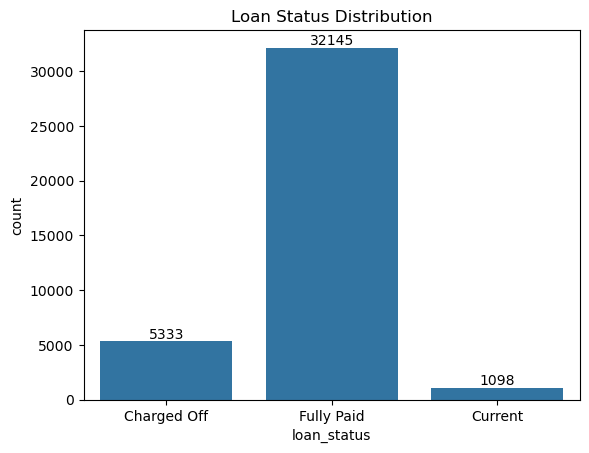

In [30]:
#(1) What proportion of loans are fully paid vs defaulted?
ax = sns.countplot(x='loan_status', data=bank_loan)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Loan Status Distribution")
plt.show()

#### Insight:

Most loans in the dataset were successfully repaid, with about 83% marked as Fully Paid, while around 14% were Charged Off, indicating default risk. Only a small portion (~3%) are still Current, meaning they are ongoing loans yet to be completed.

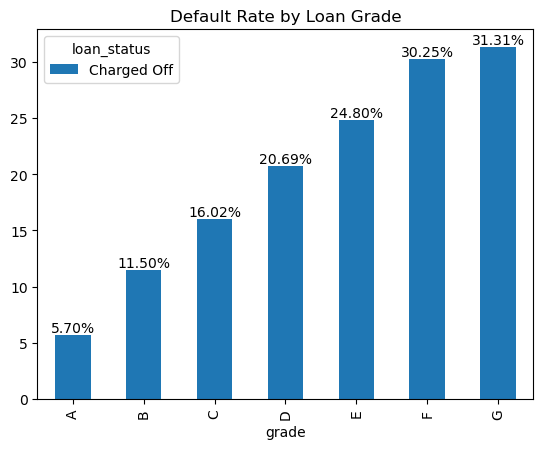

In [33]:
#(2) Which loan grades have the highest default rate?
ct = pd.crosstab(bank_loan['grade'], bank_loan['loan_status'], normalize='index')*100
ax = ct[['Charged Off']].plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')
plt.title("Default Rate by Loan Grade")
plt.show()

#### Insight:

Loan default risk increases significantly as the credit grade declines from A to G, with charged-off loans rising from ~5.7% to over 31%, indicating that lower credit grades are strongly associated with higher default probability.

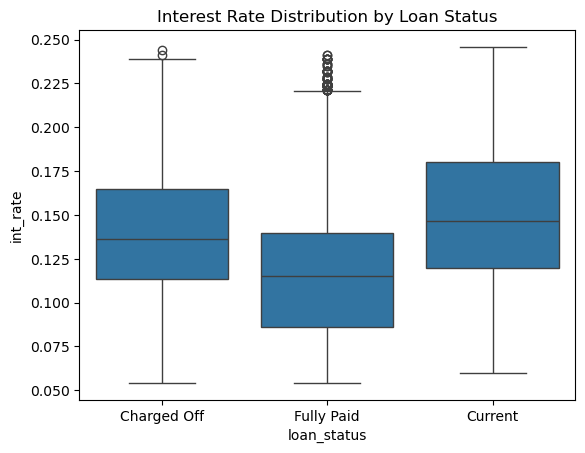

In [55]:
#(3) Do higher interest rates indicate higher loan risk?
sns.boxplot(x='loan_status', y='int_rate', data=bank_loan)
plt.title("Interest Rate Distribution by Loan Status")
plt.show()

#### Insight:
Loans with higher interest rates tend to appear more in the Charged Off category, while loans with lower interest rates are more commonly Fully Paid, suggesting that higher interest rates are generally associated with higher borrower risk and greater chances of default.

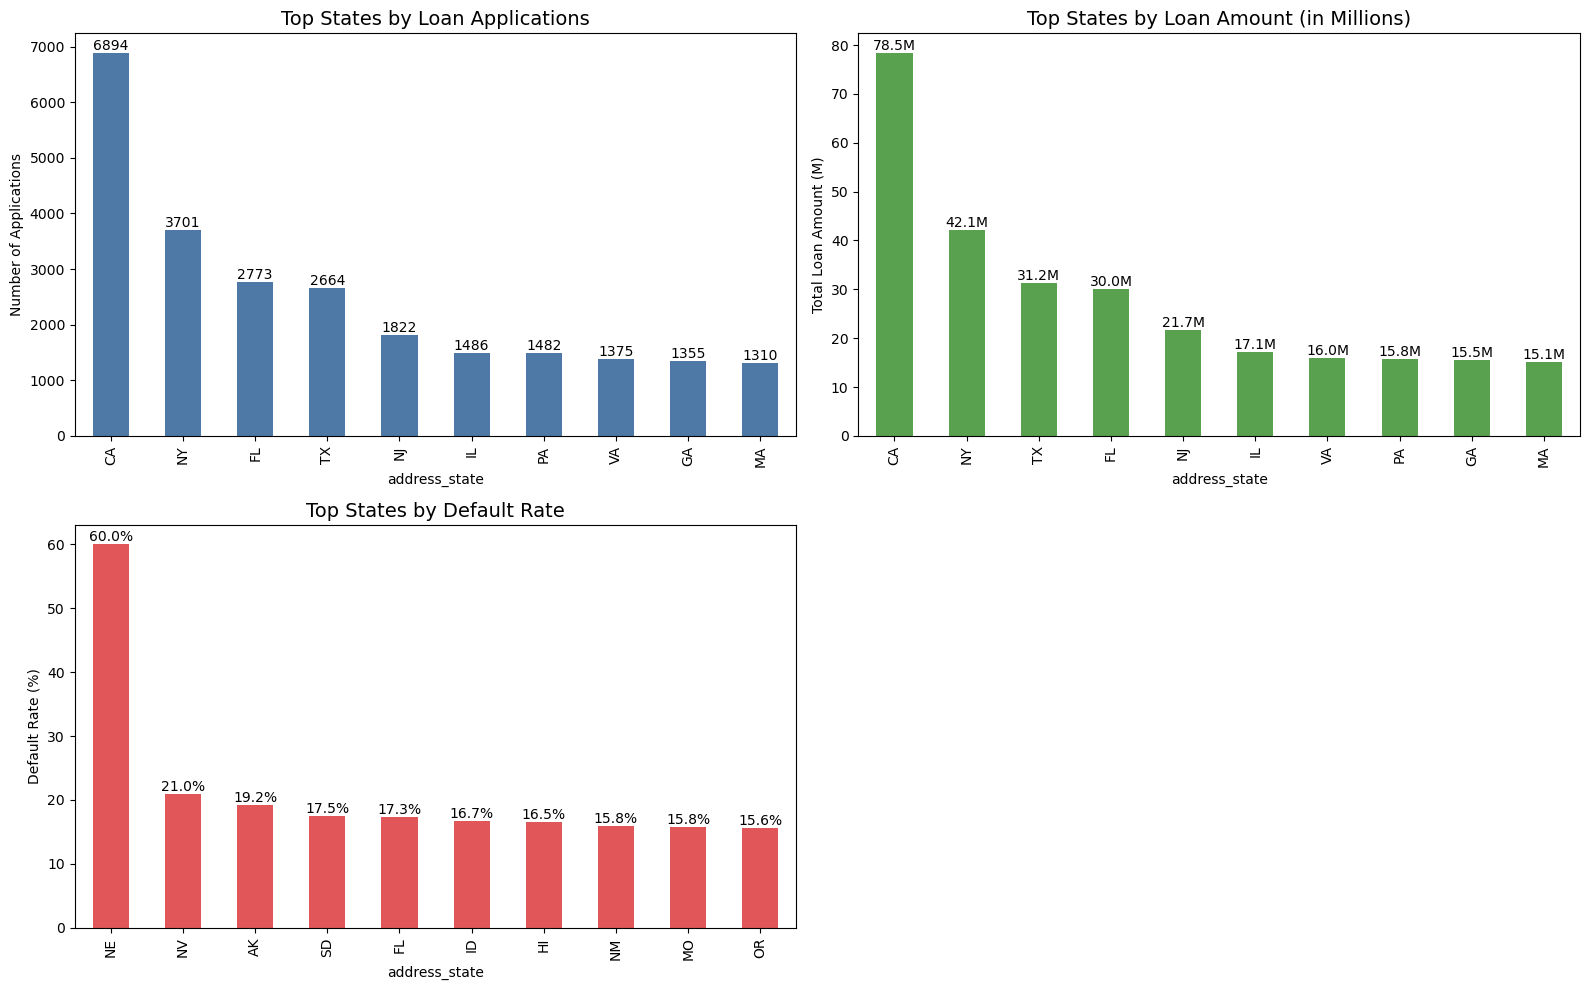

In [63]:
#(4) Which states show the highest loan demand, loan investment, and default risk?

colors = ['#4E79A7', '#59A14F', '#E15759'] 
fig, axes = plt.subplots(2, 2, figsize=(16,10))

# 1. Loan Applications
top_apps = bank_loan['address_state'].value_counts().head(10)
bars1 = top_apps.plot(kind='bar', ax=axes[0,0], color=colors[0])
axes[0,0].set_title("Top States by Loan Applications", fontsize=14)
axes[0,0].set_ylabel("Number of Applications")

for container in bars1.containers:
    bars1.bar_label(container, fmt='%d', fontsize=10)

# 2. Total Loan Amount in Millions
top_loan_amount = bank_loan.groupby('address_state')['loan_amount'].sum().sort_values(ascending=False).head(10)
top_loan_amount_m = top_loan_amount / 1000000

bars2 = top_loan_amount_m.plot(kind='bar', ax=axes[0,1], color=colors[1])
axes[0,1].set_title("Top States by Loan Amount (in Millions)", fontsize=14)
axes[0,1].set_ylabel("Total Loan Amount (M)")

for container in bars2.containers:
    bars2.bar_label(container, fmt='%.1fM', fontsize=10)

# 3. Default Rate
state_default = pd.crosstab(bank_loan['address_state'], bank_loan['loan_status'], normalize='index') * 100
top_default = state_default['Charged Off'].sort_values(ascending=False).head(10)

bars3 = top_default.plot(kind='bar', ax=axes[1,0], color=colors[2])
axes[1,0].set_title("Top States by Default Rate", fontsize=14)
axes[1,0].set_ylabel("Default Rate (%)")

for container in bars3.containers:
    bars3.bar_label(container, fmt='%.1f%%', fontsize=10)

# Hide the empty subplot
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

#### Insight:

States like California and New York show both high loan application volume and high total loan amounts, indicating strong demand and making them key markets for lending expansion. However, some states such as Maine exhibit very high default rates despite lower loan distribution, suggesting higher credit risk. This implies that while banks should prioritize lending in high-demand states, they must implement stricter credit risk assessments in regions with higher default tendencies to minimize potential losses.

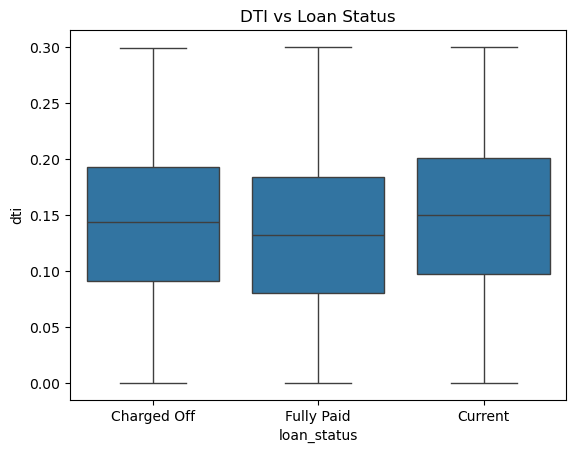

In [37]:
#(5) Are borrowers with higher DTI more likely to default?
bank_loan.groupby('loan_status')['dti'].describe()
sns.boxplot(x='loan_status', y='dti', data=bank_loan)
plt.title("DTI vs Loan Status")
plt.show()

#### Insight:

‘Current’ and ‘Charged Off’ loans have higher median and upper-range values than ‘Fully Paid’ loans, while all loans start from 0, showing that active and defaulted loans generally involve larger amounts.

### 2. Customer Profile Analysis

home_ownership
RENT        18439
MORTGAGE    17198
OWN          2838
OTHER          98
NONE            3
Name: count, dtype: int64


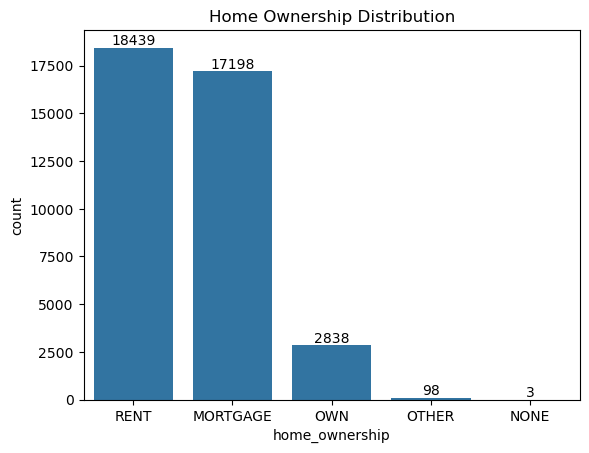

In [41]:
#(1) Which home ownership group takes the most loans?
ax = sns.countplot(x='home_ownership', data=bank_loan)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Home Ownership Distribution")
plt.show()

#### Insight:

Most borrowers in the dataset are renters (≈44%) or have a mortgage (≈41%), while a smaller fraction fully own their homes (≈7%), indicating loan applicants predominantly rely on external housing financing.

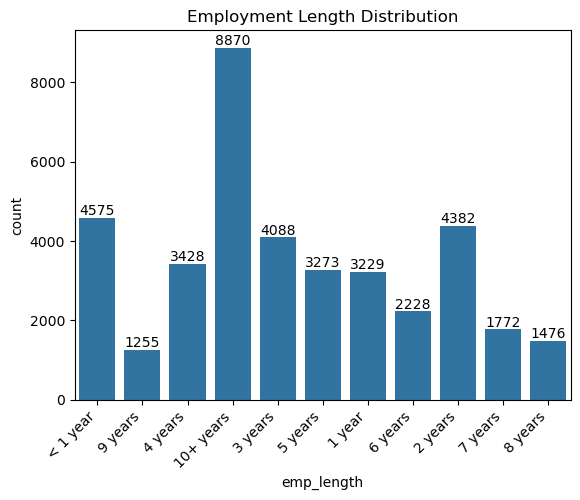

In [40]:
#(2) What is the employment experience of most borrowers?
ax = sns.countplot(x='emp_length', data=bank_loan)
plt.xticks(rotation=45, ha= 'right')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Employment Length Distribution")
plt.show()

#### Insight:

Most borrowers have long-term employment, with 10+ years being the largest group, while short-tenure employees (<1 year) also form a significant portion, indicating a mix of experienced and new professionals in the loan dataset.

### 3. Loan Performance Analysis

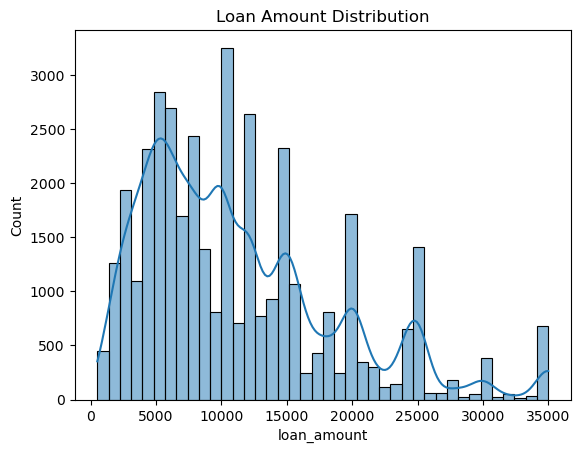

In [43]:
#(1) What is the typical loan size?
sns.histplot(bank_loan['loan_amount'], bins=40, kde= True)
plt.title("Loan Amount Distribution")
plt.show()

#### Insight:

Loan amounts are primarily concentrated between $5k, $15k, with distinct peaks around $7k, $10k, and $15k, indicating that most borrowers prefer medium-sized loans while very small or very large loans are uncommon.

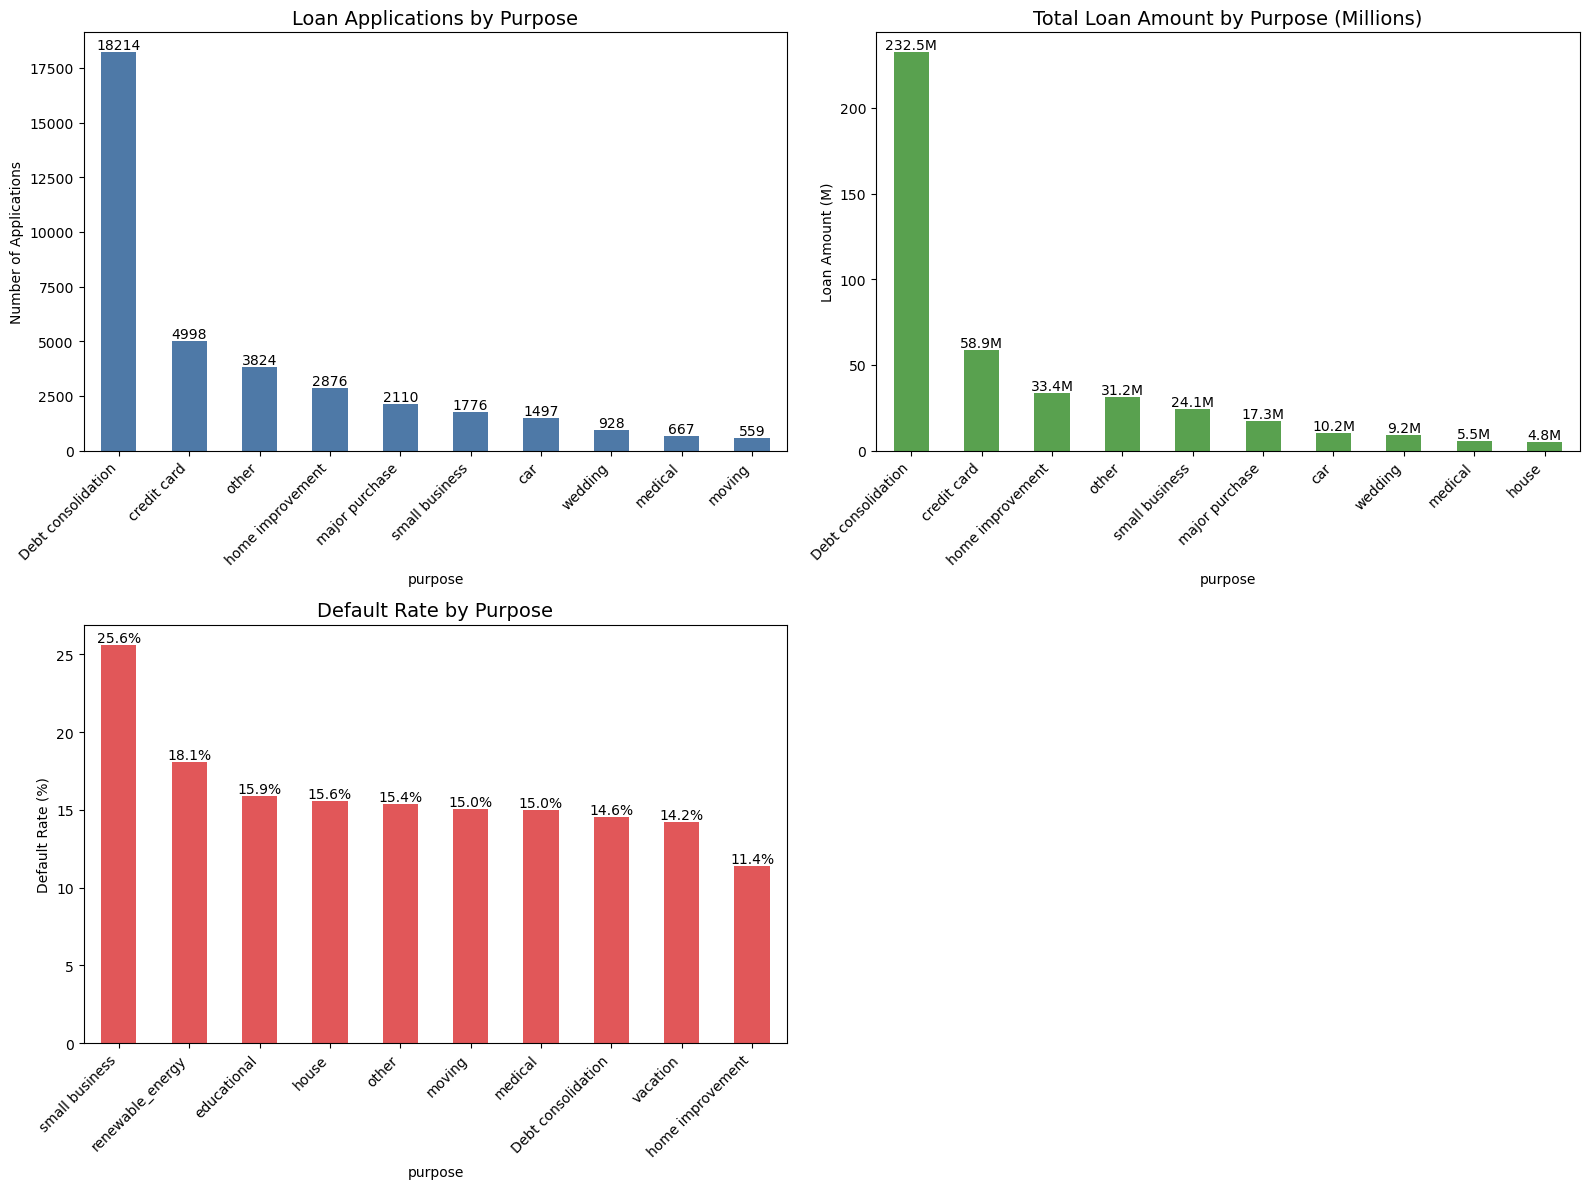

In [62]:
#(2) How does loan purpose influence loan demand, total lending amount, and default risk?

colors = ['#4E79A7', '#59A14F', '#E15759']
fig, axes = plt.subplots(2, 2, figsize=(16,12))

# Loan Applications by Purpose
top_purpose_apps = bank_loan['purpose'].value_counts().head(10)

bars1 = top_purpose_apps.plot(kind='bar', ax=axes[0,0], color=colors[0])
axes[0,0].set_title("Loan Applications by Purpose", fontsize=14)
axes[0,0].set_ylabel("Number of Applications")

for container in bars1.containers:
    bars1.bar_label(container)

axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=45, ha='right')


# Total Loan Amount by Purpose
loan_amount_purpose = bank_loan.groupby('purpose')['loan_amount'].sum().sort_values(ascending=False).head(10)
loan_amount_purpose_m = loan_amount_purpose / 1000000

bars2 = loan_amount_purpose_m.plot(kind='bar', ax=axes[0,1], color=colors[1])
axes[0,1].set_title("Total Loan Amount by Purpose (Millions)", fontsize=14)
axes[0,1].set_ylabel("Loan Amount (M)")

for container in bars2.containers:
    bars2.bar_label(container, fmt='%.1fM')

axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=45, ha='right')


# Default Rate by Purpose
purpose_default = pd.crosstab(bank_loan['purpose'], bank_loan['loan_status'], normalize='index') * 100
top_default_purpose = purpose_default['Charged Off'].sort_values(ascending=False).head(10)

bars3 = top_default_purpose.plot(kind='bar', ax=axes[1,0], color=colors[2])
axes[1,0].set_title("Default Rate by Purpose", fontsize=14)
axes[1,0].set_ylabel("Default Rate (%)")

for container in bars3.containers:
    bars3.bar_label(container, fmt='%.1f%%')

axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=45, ha='right')


# Hide last empty subplot
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

#### Insight:

Most of the loans are taken for debt consolidation, which also has the highest total loan amount, showing that borrowers mainly use loans to combine or manage existing debts. Even though the bank is investing a large amount in this category, the default rate is relatively moderate, which means it is still a fairly stable lending segment.

On the other hand, small business loans show the highest default rate, even though the number of applications and total loan amount are much lower. This indicates that lending for small businesses carries higher risk compared to other purposes.

Overall, the bank invests the most in purposes where demand is high, such as debt consolidation and credit card repayment, while some smaller categories like small business show higher default risk, suggesting that these segments may require more careful credit evaluation.

term
36 months    73.198362
60 months    26.801638
Name: proportion, dtype: float64


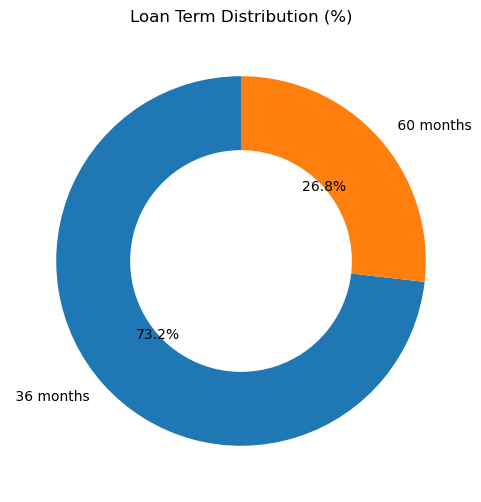

In [46]:
#(3) Do customers prefer shorter or longer loan terms?
term_percent = bank_loan['term'].value_counts(normalize=True) * 100
print(term_percent)
plt.figure(figsize=(6,6))
plt.pie(term_percent,labels=term_percent.index, autopct='%1.1f%%', startangle=90, wedgeprops={'width':0.4})
plt.title("Loan Term Distribution (%)")
plt.show()

#### Insight:

Majority of loans (≈73%) are for a 36-month term, while only about 27% are for 60 months, indicating borrowers prefer shorter loan durations.

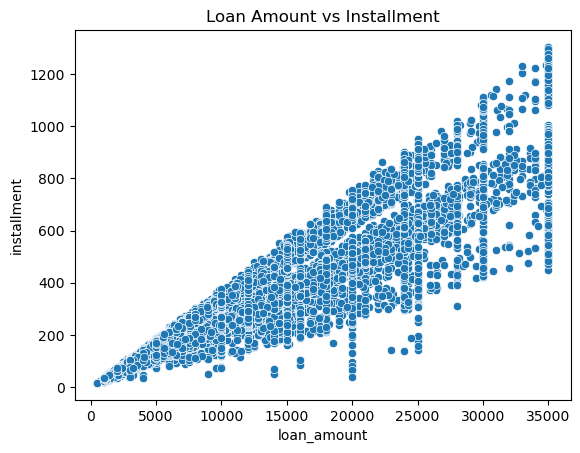

In [27]:
#(4) How does loan amount affect monthly installment?
sns.scatterplot(x='loan_amount', y='installment', data=bank_loan)
plt.title("Loan Amount vs Installment")
plt.show()

#### Insight:

Higher loan amounts result in higher monthly installments, indicating a direct proportionality between loan size and repayment amount.

### 4. Financial Behavior Analysis

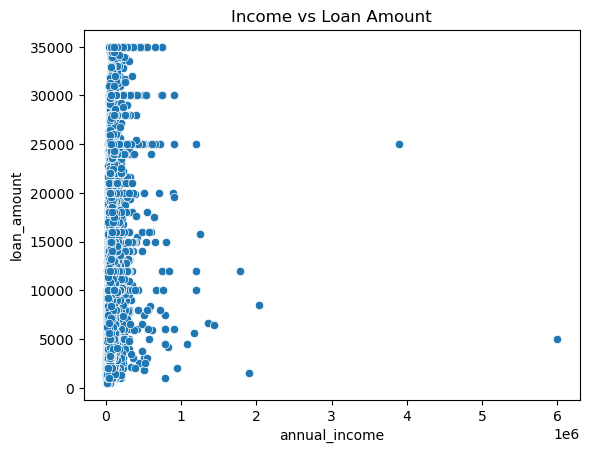

In [28]:
#(1) Do higher income borrowers take larger loans?
sns.scatterplot(x='annual_income', y='loan_amount', data=bank_loan)
plt.title("Income vs Loan Amount")
plt.show()

#### Insight:

Loan amounts are relatively independent of income for most borrowers, with the majority of loans taken by those with lower to moderate annual incomes.

### 5. Correlation Analysis

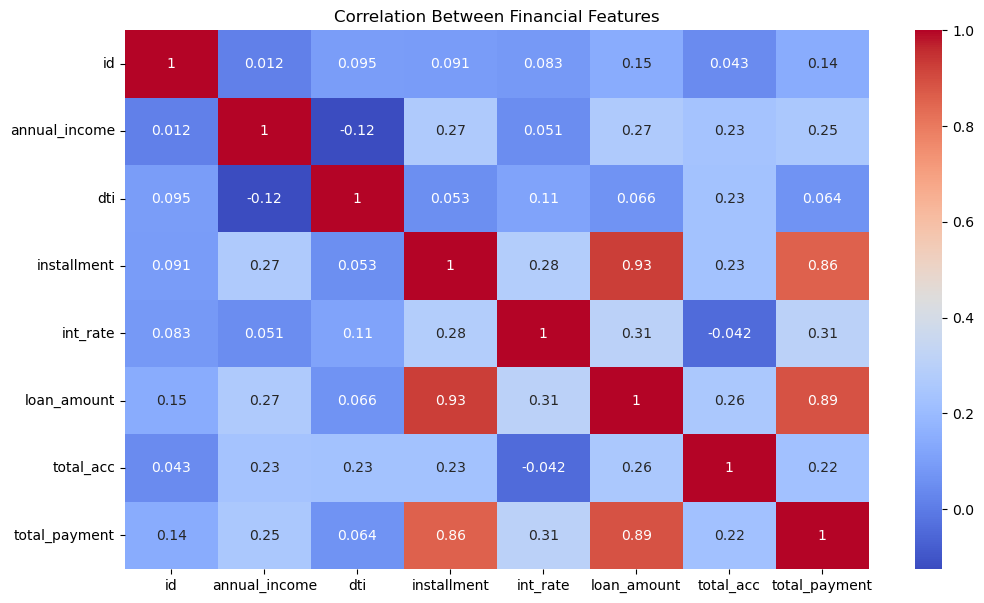

In [29]:
numeric_data = bank_loan.select_dtypes(include=np.number)
plt.figure(figsize=(12,7))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Financial Features")
plt.show()

#### Insight:
There’s a very strong positive correlation between installment & loan_amount (0.93) and loan_amount & total_payment (0.89), indicating that larger loans lead to higher monthly installments and total payments. Other financial features show weak correlations, suggesting they are relatively independent.

## Final Conclusion

- Credit grade shows a clear relationship with loan performance, as lower grades tend to have higher default rates. This indicates that borrower credit quality plays a major role in determining repayment outcomes.
- Interest rates are generally higher for loans that end up being charged off, suggesting that lenders assign higher borrowing costs to riskier applicants.
- Debt consolidation emerges as the most common loan purpose, highlighting that many borrowers rely on loans to manage existing financial obligations.
- Loan term analysis shows that 36-month loans are more common than longer repayment periods, indicating a borrower preference for shorter loan commitments.
- Financial indicators such as debt-to-income ratio also show variation across loan outcomes, with higher ratios appearing more frequently among defaulted loans.
- Overall, borrower credit grade, interest rate, and financial stability appear to be key factors associated with loan risk, while loan purpose and loan term provide insight into customer borrowing patterns.

## Business Recommendations

- Greater attention should be given to borrowers with lower credit grades, as they show higher default tendencies.

- Debt-to-income ratio should be carefully evaluated during loan approval since borrowers with higher financial obligations appear more likely to default.

- Interest rate adjustments should continue to reflect borrower risk levels, ensuring that high-risk loans are appropriately priced.

- Since debt consolidation represents the most common loan purpose, lenders may consider developing specialized loan products or monitoring strategies for this segment.

- Borrower financial stability indicators should be incorporated into risk assessment models to improve loan approval decisions.